In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [34]:
data = {
    'Date': pd.date_range('2023-01-01',periods=36,freq='ME'),
    'Sales': [
        120,125,123,130,135,140,
        138,145,150,148,155,160,
        165,170,168,175,180,185,
        190,188,195,200,205,210,
        208,215,220,225,223,230,
        235,240,245,250,248,255
    ]
}

df = pd.DataFrame(data)
df.set_index('Date', inplace=True)
df.head()

,Sales
Date,
2023-01-31,120
2023-02-28,125
2023-03-31,123
2023-04-30,130
2023-05-31,135


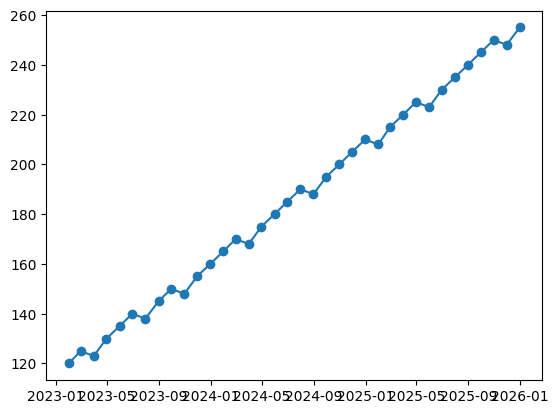

In [35]:
plt.plot(df['Sales'],marker='o')
plt.show()

In [36]:
#check ADF

result = adfuller(df['Sales'])

print('ADF Statistics:', result[0])
print('p-value', result[1])

ADF Statistics: 1.6514284585429861
p-value 0.9980039496919523


In [37]:
if result[1]<0.05:
    print('Statonory')
else:
    print('Non-Stationory')

Non-Stationory


In [38]:
# 1st Differencing

df['Sales_diff'] = df['Sales'].diff()

df_diff = df['Sales_diff'].dropna()

df_diff.head()

Date
2023-02-28    5.0
2023-03-31   -2.0
2023-04-30    7.0
2023-05-31    5.0
2023-06-30    5.0
Name: Sales_diff, dtype: float64

In [39]:

result = adfuller(df_diff)

print('ADF Statistics:', result[0])
print('p-value', result[1])

ADF Statistics: -4.328084665723592
p-value 0.0003970134755190922


In [40]:
if result[1]<0.05:
    print('Statonory')
else:
    print('Non-Stationory')

Statonory


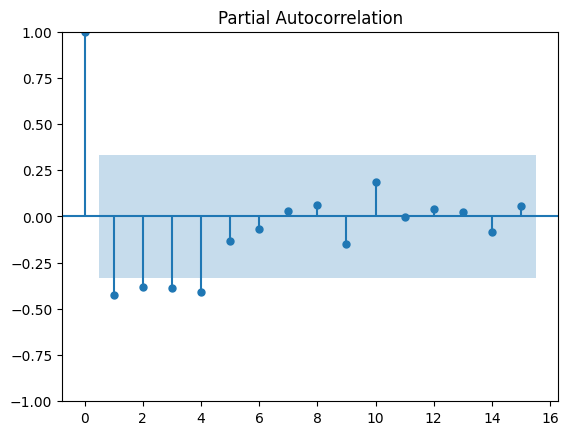

In [41]:
#Plot PACF (choose p)

plot_pacf(df_diff, lags=15)

plt.show()

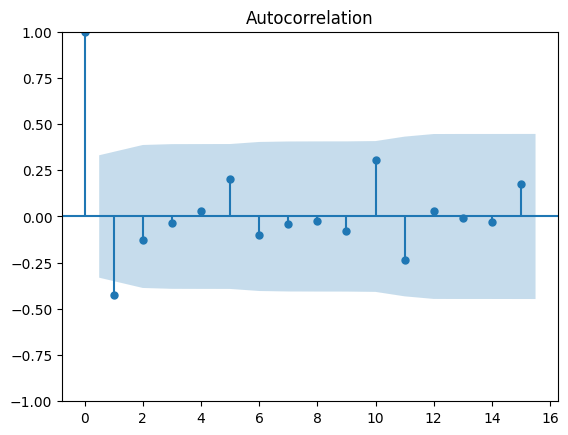

In [42]:
#plot acf (choose q)
plot_acf(df_diff,lags=15)
plt.show()

d=1,p=1,q=1

In [43]:
#Split Dataset

train = df.iloc[:30]
test = df.iloc[30:]

In [44]:
model = ARIMA(train['Sales'],order=(1,1,1))

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [45]:
model_fit = model.fit()

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [46]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   30
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -78.650
Date:                Fri, 17 Jul 2026   AIC                            163.299
Time:                        11:00:56   BIC                            167.401
Sample:                    01-31-2023   HQIC                           164.584
                         - 06-30-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.001   1313.102      0.000       0.999       1.001
ma.L1         -0.9979      0.430     -2.322      0.020      -1.840      -0.156
sigma2        11.7571      0.036    323.243      0.0

In [47]:
#Forecast

forecast = model_fit.forecast(steps=(len(test)))
print(forecast)

2025-07-31    233.686705
2025-08-31    237.373404
2025-09-30    241.060096
2025-10-31    244.746780
2025-11-30    248.433458
2025-12-31    252.120129
Freq: ME, Name: predicted_mean, dtype: float64


In [48]:
#Evaluate Model

mae = mean_absolute_error(test['Sales'], forecast)
print('MAE:',mae)

MAE: 2.741057272152934


In [49]:
#RMSE
rmse = np.sqrt(mean_squared_error(test['Sales'], forecast))
print('RMSE:',rmse)

RMSE: 3.168187003871073


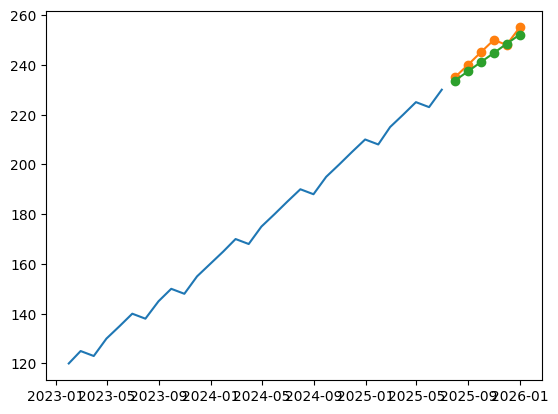

In [50]:
plt.plot(train.index,train['Sales'],label='Train')
plt.plot(test.index, test['Sales'], marker='o', label='Actual')
plt.plot(test.index,forecast,marker='o',label='Forecast')

plt.show()

In [51]:
model = ARIMA(df['Sales'], order=(1,1,1))
model_fit = model.fit()

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [52]:
future_forecast = model_fit.forecast(steps=6)
print(future_forecast)

2026-01-31    258.774661
2026-02-28    262.549296
2026-03-31    266.323905
2026-04-30    270.098487
2026-05-31    273.873043
2026-06-30    277.647574
Freq: ME, Name: predicted_mean, dtype: float64


In [53]:
future_dates = pd.date_range(
    start=df.index[-1] + pd.offsets.MonthEnd(),
    periods=6,
    freq="ME"
)

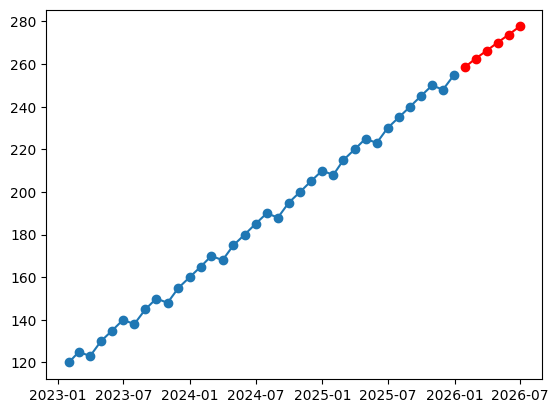

In [54]:
plt.plot(df.index,df['Sales'],marker='o')
plt.plot(future_dates,future_forecast,marker='o',color='red',label='future forecase')
plt.show()

# Project 2

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller 
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.arima.model import ARIMA

In [56]:
data = {
    'Date': pd.date_range('2024-01-01',periods=36,freq='ME'),
    'Sales':[
        120,125,123,130,135,140,
        138,145,150,148,155,160,
        165,170,168,175,180,185,
        190,188,195,200,205,210,
        208,215,220,225,223,230,
        235,240,245,250,248,255
    ]
}

df = pd.DataFrame(data)
df.set_index(df['Date'], inplace=True)
df.head()

,Date,Sales
Date,,
2024-01-31,2024-01-31,120
2024-02-29,2024-02-29,125
2024-03-31,2024-03-31,123
2024-04-30,2024-04-30,130
2024-05-31,2024-05-31,135


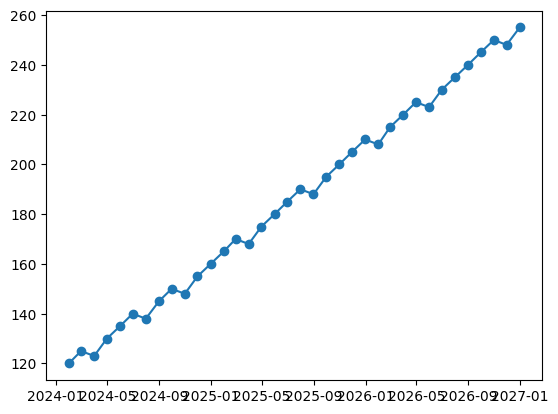

In [57]:
plt.plot(df['Sales'],marker='o')
plt.show()

In [58]:
results = adfuller(df['Sales'])

print('ADF Statistics:',results[0])
print('p-value:',results[1])

ADF Statistics: 1.6514284585429861
p-value: 0.9980039496919523


In [59]:
df['Sales_diff'] = df['Sales'].diff()
diff_df = df['Sales_diff'].dropna()

In [60]:
results = adfuller(diff_df)

print('ADF Statistics:',results[0])
print('p-value:',results[1])

ADF Statistics: -4.328084665723592
p-value: 0.0003970134755190922


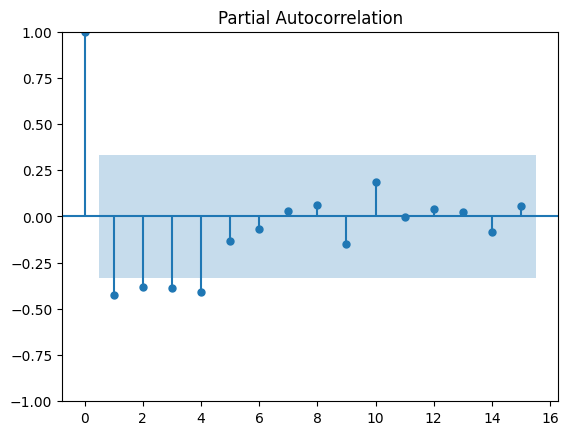

In [61]:
# choose p

plot_pacf(diff_df,lags=15)
plt.show()

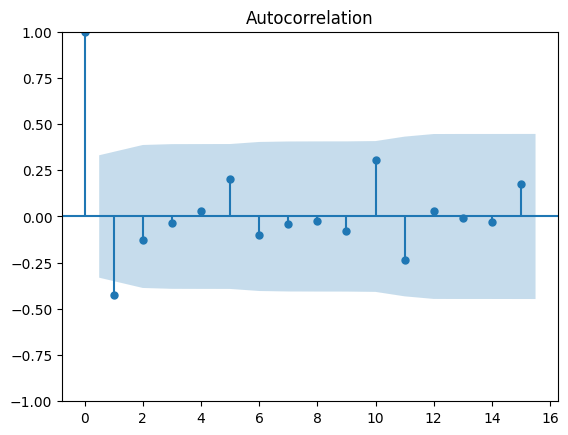

In [62]:
plot_acf(diff_df,lags=15)
plt.show()

In [67]:
model = ARIMA(train['Sales'], order=(1,1,1))
model_fit = model.fit()

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [68]:
train = df.iloc[:30]
test = df.iloc[30:]

In [69]:
forecast = model_fit.forecast(steps=(len(test)))

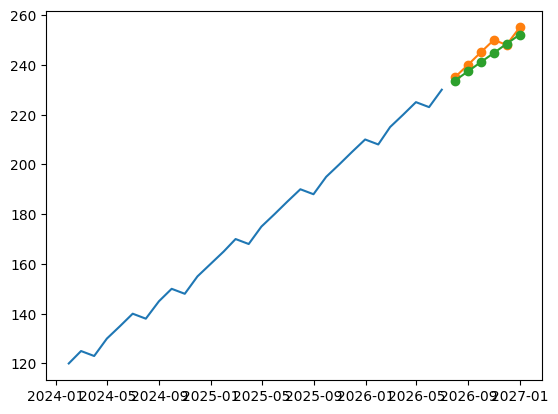

In [70]:
plt.plot(train.index, train['Sales'], label="Train")
plt.plot(test.index, test['Sales'],marker='o', label='Actual')
plt.plot(test.index,forecast,marker='o',label='Predicted')

plt.show()


In [75]:
future_date = pd.date_range(
    start = df.index[-1] + pd.offsets.MonthEnd(),periods=6,freq='ME'
)

model = ARIMA(df['Sales'], order=(1,1,1))
model_fit = model.fit()

future_forecast = model_fit.forecast(steps=6)

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


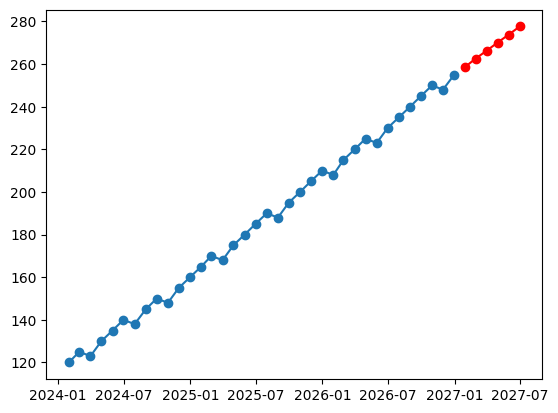

In [76]:
plt.plot(df['Sales'],marker='o')
plt.plot(future_date,future_forecast,marker='o',color='red',label='Predicted')
plt.show()